# 1. import, setup, dan konfigurasi

In [2]:
import sys
import logging
from pathlib import Path
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# auto detect project root
current_dir = Path.cwd()
project_root = current_dir.parent

# konfigurasi sys.path dan tambah project root ke system path
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
    
# import
from src import (
    kmeans, 
    kmeans_pp, 
    choose_k_elbow, 
    choose_k_silhouette, 
    calculate_sse
)

# konfifurasi logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler(sys.stdout)]
)

# konfigurasi folder output dan otomatisasi penamaan file
# output_dir = project_root / "output"
# output_dir.mkdir(parents=True, exist_ok=True)

# def generate_output_path(prefix="plot", ext=".png"):
#     timestamp = datetime.now().strftime("%Y%m%d_%H%M")
#     filename = f"{prefix}_{timestamp}{ext}"
#     return output_dir / filename

logging.info(f"project root: {project_root}")

# load data
data_path = project_root / "data" / "Iris.csv"
logging.info(f"dataset: {data_path}")
df_iris = pd.read_csv(data_path)
display(df_iris.head())

2026-03-09 16:22:05,073 - INFO - project root: /home/cation-ub/documents/kelompokD_sk5004/kmeans
2026-03-09 16:22:05,080 - INFO - dataset: /home/cation-ub/documents/kelompokD_sk5004/kmeans/data/Iris.csv


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


# 2. preprocessing
dataset yang digunakan untuk menguji algoritma adalah: [Iris Species](https://www.kaggle.com/datasets/uciml/iris).

* menghilangkan kolom Id
* menghilangkan kolom Species (label)
* menyimpan label untuk perbandingan nanti

In [3]:
df_iris = df_iris.drop('Id', axis=1)
true_labels = df_iris['Species'].values
x = df_iris.drop('Species', axis=1).values

logging.info(f"bentuk matriks data x: {x.shape}")

2026-03-09 16:22:17,971 - INFO - bentuk matriks data x: (150, 4)


# 3. pipeline:
1. choose k menggunakan k-means++ -> mendapatkan best k
2. menentukan best k final jika hasil elbow dan silhouette berbeda: ambil salah satu atau rata2
3. run algoritma classic k-means dan k-means++
4. plot. karena datasetnya 4 dimensi, dilakukan reduksi dimensi, jadi 2 fitur pertama dipilih untuk plotting 2D scatter plot

2026-03-09 16:38:45,350 - INFO - running metode elbow...


elbow evaluation:   0%|                                                                                                                                                                   | 0/8 [00:00<?, ?it/s]

2026-03-09 16:38:45,357 - INFO - running k-means++ dengan k=1



k-means++ iterations:   0%|                                                                                                                                                             | 0/100 [00:00<?, ?it/s]

2026-03-09 16:38:45,370 - INFO - k-means++ konvergen pada iterasi ke-2


...

2026-03-09 16:38:45,537 - INFO - running k-means++ dengan k=8




k-means++ iterations:   0%|                                                                                                                                                             | 0/100 [00:00<?, ?it/s]

2026-03-09 16:38:45,564 - INFO - k-means++ konvergen pada iterasi ke-11


elbow evaluation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 37.41it/s]

2026-03-09 16:38:45,577 - INFO - metode elbow menyarankan k=2


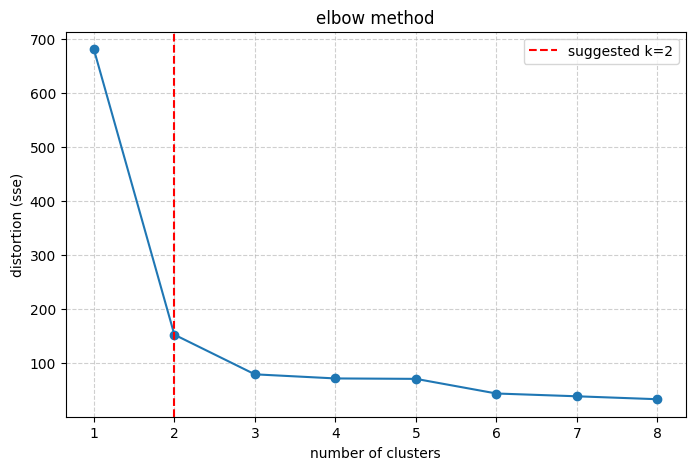

2026-03-09 16:38:45,978 - INFO - running metode silhouette...


silhouette evaluation:   0%|                                                                                                                                                              | 0/7 [00:00<?, ?it/s]

2026-03-09 16:38:45,985 - INFO - running k-means++ dengan k=2



k-means++ iterations:   0%|                                                                                                                                                             | 0/100 [00:00<?, ?it/s]

2026-03-09 16:38:45,998 - INFO - k-means++ konvergen pada iterasi ke-3


...

2026-03-09 16:38:46,831 - INFO - running k-means++ dengan k=8



k-means++ iterations:   0%|                                                                                                                                                             | 0/100 [00:00<?, ?it/s]

2026-03-09 16:38:46,854 - INFO - k-means++ konvergen pada iterasi ke-11


silhouette evaluation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:01<00:00,  6.32it/s]

2026-03-09 16:38:47,095 - INFO - metode silhouette menyarankan k=2 (score maksimum: 0.6808)


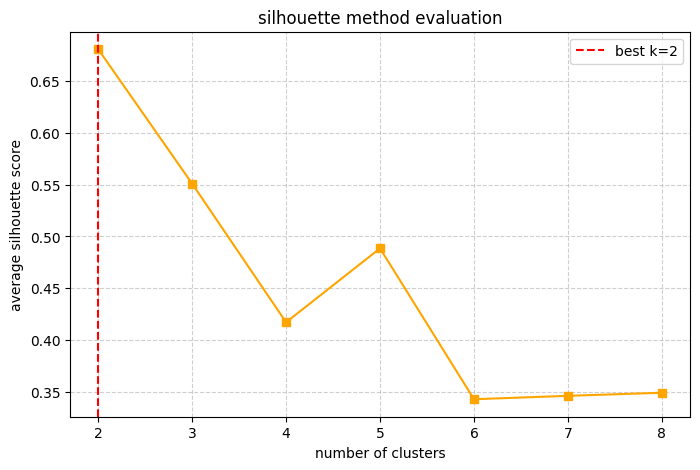

2026-03-09 16:38:47,473 - INFO - final k = 2
2026-03-09 16:38:47,475 - INFO - running classic k-means dengan k=2


k-means iterations:   0%|                                                                                                                                                               | 0/100 [00:00<?, ?it/s]

2026-03-09 16:38:47,487 - INFO - k-means konvergen pada iterasi ke-7


k-means iterations:   6%|█████████                                                                                                                                             | 6/100 [00:00<00:00, 909.76it/s]

2026-03-09 16:38:47,492 - INFO - running k-means++ dengan k=2



k-means++ iterations:   0%|                                                                                                                                                             | 0/100 [00:00<?, ?it/s]

2026-03-09 16:38:47,504 - INFO - k-means++ konvergen pada iterasi ke-6


k-means++ iterations:   5%|███████▍                                                                                                                                            | 5/100 [00:00<00:00, 984.62it/s]


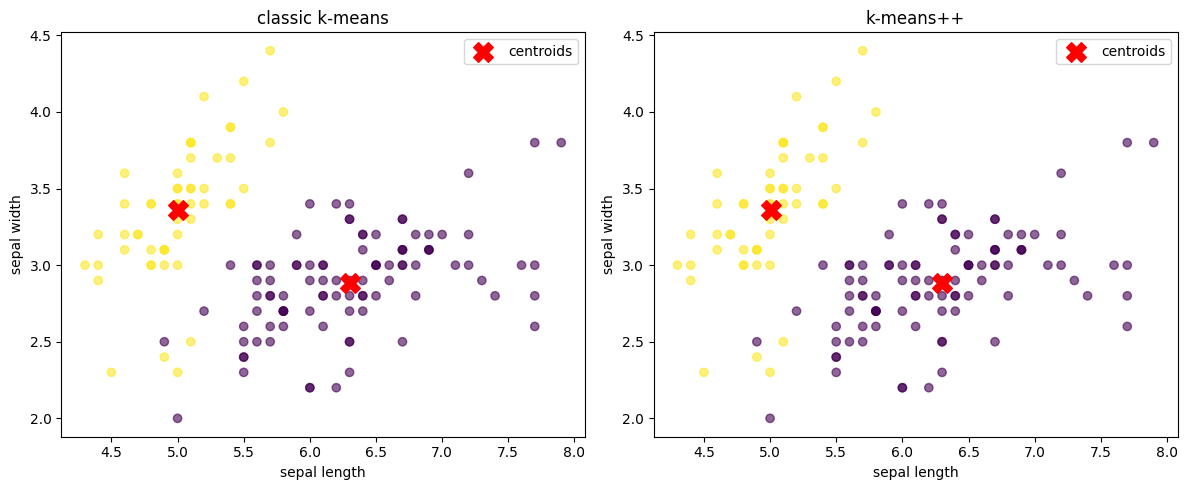

In [6]:
## 3.1 choose k
best_k_elbow = choose_k_elbow(x, kmeans_pp, max_k=8, plot=True)
best_k_silhouette = choose_k_silhouette(x, kmeans_pp, max_k=8, plot=True)

## 3.2 menentukan best k final
final_k = best_k_silhouette if best_k_elbow == best_k_silhouette else best_k_silhouette
logging.info(f"final k = {final_k}")

## 3.3 run kedua algoritma dengan final_k
labels_classic, centroids_classic = kmeans(x, final_k)
labels_pp, centroids_pp = kmeans_pp(x, final_k)

## 3.4 plotting

### label alignment
def align_labels(centroids_ref, labels_target, centroids_target):
    mapping = {}
    for i, c_target in enumerate(centroids_target):
        # cari centroid yg jaraknya paling dekat dengan c_target
        distances = np.sum((centroids_ref - c_target)**2, axis=1)
        closest_idx = np.argmin(distances)
        mapping[i] = closest_idx
    # buat array label baru
    aligned_labels = np.array([mapping[label] for label in labels_target])
    return aligned_labels
### terapkan ke k-means++
labels_pp = align_labels(centroids_classic, labels_pp, centroids_pp)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

### plot classic k-means
ax1.scatter(x[:, 0], x[:, 1], c=labels_classic, cmap='viridis', alpha=0.6)
ax1.scatter(centroids_classic[:, 0], centroids_classic[:, 1], c='red', marker='X', s=200, label='centroids')
ax1.set_title('classic k-means')
ax1.set_xlabel('sepal length')
ax1.set_ylabel('sepal width')
ax1.legend()

### plot k-means++
ax2.scatter(x[:, 0], x[:, 1], c=labels_pp, cmap='viridis', alpha=0.6)
ax2.scatter(centroids_pp[:, 0], centroids_pp[:, 1], c='red', marker='X', s=200, label='centroids')
ax2.set_title('k-means++')
ax2.set_xlabel('sepal length')
ax2.set_ylabel('sepal width')
ax2.legend()

plt.tight_layout()
plt.show()